# Семинар 2. Исследование методов линейной регрессии

#### Критерий оценивания:
#### Пункт 14: максимум 0,5 балла
#### Пункт 15: максимум 0,5 балла

#### Итого за работу: максимум 1 балл
#### P.S. пункты 14 и 15 без пунктов 1-13 не засчитываются, ответы на вопросы из ИИ не засчитываются

1. Загрузите датасет и выведите на экран первые несколько строк

In [13]:
import pandas as pd

data = pd.read_csv('auto_dataset.csv')

data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


2. Разбейте выборку на признаки и ответы. Закодируйте категориальные признаки.

In [14]:
X_raw = data.drop(columns='price')
y = data['price'].astype(float)

categorical_columns = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()

X = pd.get_dummies(X_raw, columns=categorical_columns, drop_first=True, dtype=float)

X.head()

,powerPS,kilometer,autoAgeMonths,brand_audi,brand_bmw,brand_chevrolet,brand_chrysler,brand_citroen,brand_dacia,brand_daewoo,...,vehicleType_kleinwagen,vehicleType_kombi,vehicleType_limousine,vehicleType_suv,gearbox_manuell,fuelType_benzin,fuelType_diesel,fuelType_hybrid,fuelType_lpg,notRepairedDamage_nein
0,75,150000,177,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,69,90000,93,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,102,150000,246,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,109,150000,140,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,105,150000,136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


3. Разбейте датасет на train val test в отношении 8:1:1

In [15]:
from sklearn.model_selection import train_test_split


X_train, X_temp, y_train, y_temp = train_test_split(
      X, y, test_size=0.2, random_state=42)

  # Делим оставшиеся 20% пополам: 10% validation и 10% test
X_val, X_test, y_val, y_test = train_test_split(
      X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (800, 204)
Validation: (100, 204)
Test: (100, 204)


4. Исследуйте VGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

In [34]:
%matplotlib inline
import matplotlib.pyplot as plt

def plot_losses(table, title):
    parameter = table.columns[0]

    # Исключаем расходящиеся шаги
    valid = np.isfinite(table["Loss_train"]) & np.isfinite(table["Loss_val"])
    table = table[valid]

    best_index = table["Loss_val"].idxmin()
    best_step = table.loc[best_index, parameter]

    plt.figure(figsize=(8, 4))
    plt.plot(
        table[parameter], table["Loss_train"],
        "o--", color="steelblue", label="Train"
    )
    plt.plot(
        table[parameter], table["Loss_val"],
        "s-", color="darkorange", label="Validation"
    )
    plt.axvline(
        best_step, color="black", linestyle=":",
        label="Лучший шаг"
    )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(parameter)
    plt.ylabel("MSE")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

,Шаг,Loss_train,R2_train,Loss_val,Итерации
0,0.00001,8.350049e+07,-0.371955,8.006857e+07,5000
1,0.00010,2.222627e+07,0.634811,2.032179e+07,5000
2,0.00100,1.271979e+07,0.791007,1.689811e+07,5000
3,0.01000,1.211564e+07,0.800934,1.755366e+07,5000
4,0.10000,1.202832e+07,0.802369,1.839746e+07,5000
5,1.00000,inf,NaN,inf,11


,Метод,Лучший шаг,Loss_train,Loss_val,Loss_test,R2_train,R2_test,Итерации
0,VGD с постоянным шагом,0.001,1.271979e+07,1.689811e+07,2.878046e+07,0.791007,0.587303,5000


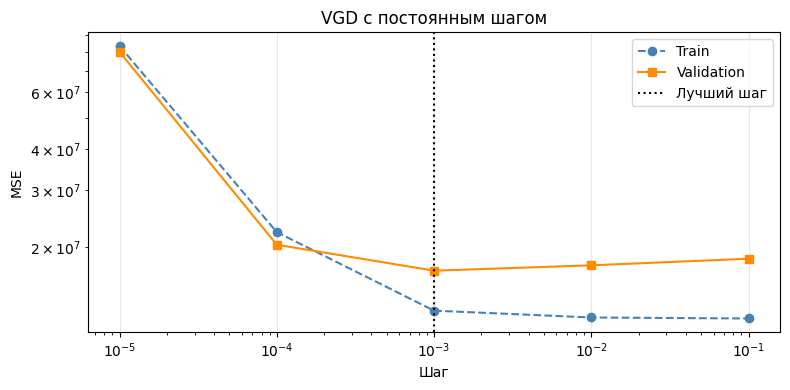

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Масштабируем признаки, используя только train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Добавляем столбец единиц для свободного члена
A_train = np.column_stack([np.ones(len(X_train)), X_train_scaled])
A_val = np.column_stack([np.ones(len(X_val)), X_val_scaled])
A_test = np.column_stack([np.ones(len(X_test)), X_test_scaled])

# VGD с постоянным шагом
def train_vgd(A, y, step, max_iter=5000):
    weights = np.zeros(A.shape[1])
    y = np.asarray(y)

    for iteration in range(max_iter):
        predictions = A @ weights
        gradient = 2 / len(y) * A.T @ (predictions - y)
        new_weights = weights - step * gradient

        # Слишком большой шаг может вызвать расходимость
        if not np.isfinite(new_weights).all() or np.linalg.norm(new_weights) > 1e12:
              return None, iteration + 1

        difference = np.linalg.norm(new_weights - weights)
        weights = new_weights

        if difference < 1e-6:
            break

    return weights, iteration + 1


steps = np.logspace(-5, 0, 6)
results = []
models = []

for step in steps:
    weights, iterations = train_vgd(A_train, y_train, step)
    models.append(weights)

    if weights is None:
        results.append({
            "Шаг": step,
            "Loss_train": np.inf,
            "R2_train": np.nan,
            "Loss_val": np.inf,
            "Итерации": iterations
        })
        continue

    train_predictions = A_train @ weights
    val_predictions = A_val @ weights

    results.append({
        "Шаг": step,
        "Loss_train": mean_squared_error(y_train, train_predictions),
        "R2_train": r2_score(y_train, train_predictions),
        "Loss_val": mean_squared_error(y_val, val_predictions),
        "Итерации": iterations
    })

results_vgd = pd.DataFrame(results)
display(results_vgd)

# Выбираем лучший шаг только по ошибке на validation
best_index = results_vgd["Loss_val"].idxmin()
best_weights = models[best_index]

# Оцениваем выбранную модель на test
test_predictions = A_test @ best_weights

vgd_constant_result = {
    "Метод": "VGD с постоянным шагом",
    "Лучший шаг": results_vgd.loc[best_index, "Шаг"],
    "Loss_train": results_vgd.loc[best_index, "Loss_train"],
    "Loss_val": results_vgd.loc[best_index, "Loss_val"],
    "Loss_test": mean_squared_error(y_test, test_predictions),
    "R2_train": results_vgd.loc[best_index, "R2_train"],
    "R2_test": r2_score(y_test, test_predictions),
    "Итерации": int(results_vgd.loc[best_index, "Итерации"])
}

display(pd.DataFrame([vgd_constant_result]))
plot_losses(results_vgd, "VGD с постоянным шагом")

5. Исследуйте VGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

,Лямбда,Loss_train,R2_train,Loss_val,Итерации
0,0.00001,1.083963e+08,-0.781005,1.062791e+08,5000
1,0.00010,1.009417e+08,-0.658523,9.838721e+07,5000
2,0.00100,5.610670e+07,0.078139,5.199630e+07,5000
3,0.01000,1.360320e+07,0.776493,1.529679e+07,5000
4,0.10000,1.241402e+07,0.796031,1.742411e+07,5000
5,1.00000,1.203356e+07,0.802283,1.797560e+07,5000


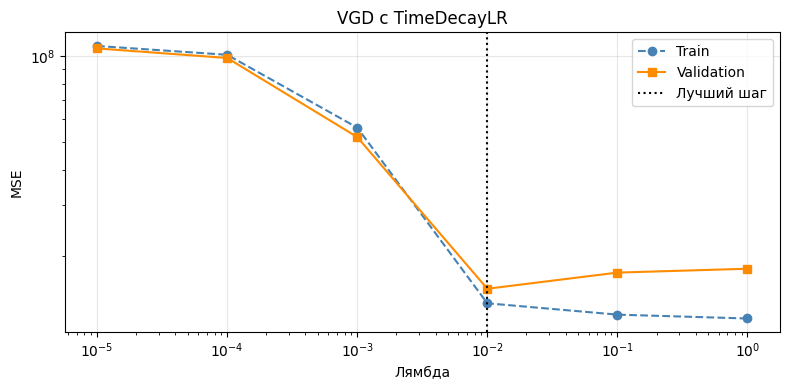

In [36]:
def train_vgd_decay(A, y, learning_rate, max_iter=5000):
    weights = np.zeros(A.shape[1])
    y = np.asarray(y)

    for iteration in range(max_iter):
        predictions = A @ weights
        gradient = 2 / len(y) * A.T @ (predictions - y)

        # TimeDecayLR: η(k) = λ / sqrt(1 + k)
        current_step = learning_rate / np.sqrt(1 + iteration)
        new_weights = weights - current_step * gradient

        if not np.isfinite(new_weights).all() or np.linalg.norm(new_weights) > 1e12:
            return None, iteration + 1

        difference = np.linalg.norm(new_weights - weights)
        weights = new_weights

        if difference < 1e-6:
            break

    return weights, iteration + 1


learning_rates = np.logspace(-5, 0, 6)
results = []
models = []

for learning_rate in learning_rates:
    weights, iterations = train_vgd_decay(
        A_train, y_train, learning_rate
    )
    models.append(weights)

    if weights is None:
        results.append({
            "Лямбда": learning_rate,
            "Loss_train": np.inf,
            "R2_train": np.nan,
            "Loss_val": np.inf,
            "Итерации": iterations
        })
        continue

    train_predictions = A_train @ weights
    val_predictions = A_val @ weights

    results.append({
        "Лямбда": learning_rate,
        "Loss_train": mean_squared_error(y_train, train_predictions),
        "R2_train": r2_score(y_train, train_predictions),
        "Loss_val": mean_squared_error(y_val, val_predictions),
        "Итерации": iterations
    })

results_vgd_decay = pd.DataFrame(results)
display(results_vgd_decay)

# Выбираем лямбда по минимальной ошибке на validation
best_index = results_vgd_decay["Loss_val"].idxmin()
best_weights = models[best_index]
best_lambda = results_vgd_decay.loc[best_index, "Лямбда"]

# Оцениваем выбранную модель на test
test_predictions = A_test @ best_weights

vgd_decay_result = {
    "Метод": "VGD с TimeDecayLR",
    "Лучший шаг": f"{best_lambda:.6g} / sqrt(1 + k)",
    "Loss_train": results_vgd_decay.loc[best_index, "Loss_train"],
    "Loss_val": results_vgd_decay.loc[best_index, "Loss_val"],
    "Loss_test": mean_squared_error(y_test, test_predictions),
    "R2_train": results_vgd_decay.loc[best_index, "R2_train"],
    "R2_test": r2_score(y_test, test_predictions),
    "Итерации": int(results_vgd_decay.loc[best_index, "Итерации"])
}
pd.DataFrame([vgd_decay_result])
plot_losses(results_vgd_decay, "VGD с TimeDecayLR")

6. Исследуйте SGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

,Шаг,Loss_train,R2_train,Loss_val,Итерации
0,0.00001,8.307610e+07,-0.364982,7.802197e+07,5000
1,0.00010,2.133809e+07,0.649404,1.869156e+07,5000
2,0.00100,9.103824e+10,-1494.803868,9.105593e+07,5000
3,0.01000,inf,NaN,inf,923
4,0.10000,inf,NaN,inf,64
5,1.00000,inf,NaN,inf,9


,Метод,Лучший шаг,Loss_train,Loss_val,Loss_test,R2_train,R2_test,Итерации
0,SGD с постоянным шагом,0.0001,2.133809e+07,1.869156e+07,3.906959e+07,0.649404,0.439762,5000


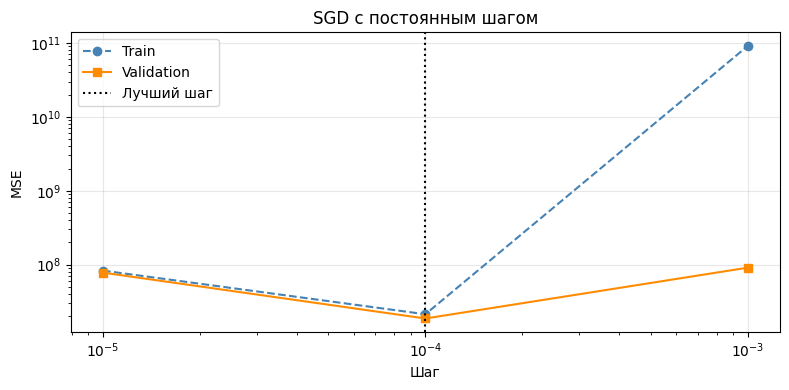

In [37]:
def train_sgd(A, y, step, max_iter=5000):
    weights = np.zeros(A.shape[1])
    y = np.asarray(y)
    rng = np.random.default_rng(42)

    for iteration in range(max_iter):
        # Выбираем один случайный объект
        index = rng.integers(len(y))

        prediction = A[index] @ weights
        gradient = 2 * (prediction - y[index]) * A[index]
        new_weights = weights - step * gradient

        if not np.isfinite(new_weights).all() or np.linalg.norm(new_weights) > 1e12:
            return None, iteration + 1

        weights = new_weights

    return weights, max_iter


steps = np.logspace(-5, 0, 6)
results = []
models = []

for step in steps:
    weights, iterations = train_sgd(A_train, y_train, step)
    models.append(weights)

    if weights is None:
        results.append({
            "Шаг": step,
            "Loss_train": np.inf,
            "R2_train": np.nan,
            "Loss_val": np.inf,
            "Итерации": iterations
        })
        continue

    train_predictions = A_train @ weights
    val_predictions = A_val @ weights

    results.append({
        "Шаг": step,
        "Loss_train": mean_squared_error(y_train, train_predictions),
        "R2_train": r2_score(y_train, train_predictions),
        "Loss_val": mean_squared_error(y_val, val_predictions),
        "Итерации": iterations
    })

results_sgd = pd.DataFrame(results)
display(results_sgd)

# Выбираем лучший шаг по ошибке на validation
best_index = results_sgd["Loss_val"].idxmin()
best_weights = models[best_index]

# Оцениваем выбранную модель на test
test_predictions = A_test @ best_weights

sgd_constant_result = {
    "Метод": "SGD с постоянным шагом",
    "Лучший шаг": results_sgd.loc[best_index, "Шаг"],
    "Loss_train": results_sgd.loc[best_index, "Loss_train"],
    "Loss_val": results_sgd.loc[best_index, "Loss_val"],
    "Loss_test": mean_squared_error(y_test, test_predictions),
    "R2_train": results_sgd.loc[best_index, "R2_train"],
    "R2_test": r2_score(y_test, test_predictions),
    "Итерации": int(results_sgd.loc[best_index, "Итерации"])
}

display(pd.DataFrame([sgd_constant_result]))
plot_losses(results_sgd, "SGD с постоянным шагом")

7. Исследуйте SGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

,Лямбда,Loss_train,R2_train,Loss_val,Итерации
0,0.00001,1.084201e+08,-0.781397,1.062357e+08,5000
1,0.00010,1.011486e+08,-0.661922,9.798283e+07,5000
2,0.00100,5.652665e+07,0.071239,5.006515e+07,5000
3,0.01000,1.420092e+07,0.766672,1.591735e+07,5000
4,0.10000,inf,NaN,inf,4130
5,1.00000,inf,NaN,inf,14


,Метод,Лучший шаг,Loss_train,Loss_val,Loss_test,R2_train,R2_test,Итерации
0,SGD с TimeDecayLR,0.01 / sqrt(1 + k),1.420092e+07,1.591735e+07,3.134007e+07,0.766672,0.550599,5000


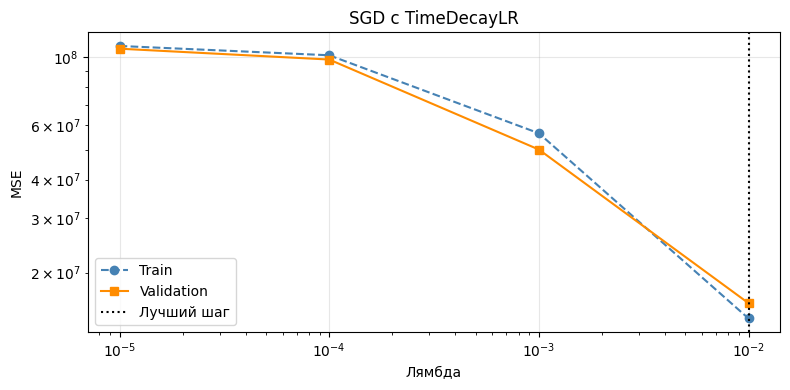

In [38]:
def train_sgd_decay(A, y, learning_rate, max_iter=5000):
    weights = np.zeros(A.shape[1])
    y = np.asarray(y)
    rng = np.random.default_rng(42)

    for iteration in range(max_iter):
        # Выбираем один случайный объект
        index = rng.integers(len(y))

        prediction = A[index] @ weights
        gradient = 2 * (prediction - y[index]) * A[index]

        # TimeDecayLR из лекции
        current_step = learning_rate / np.sqrt(1 + iteration)
        new_weights = weights - current_step * gradient

        if not np.isfinite(new_weights).all() or np.linalg.norm(new_weights) > 1e12:
            return None, iteration + 1

        weights = new_weights

    return weights, max_iter


learning_rates = np.logspace(-5, 0, 6)
results = []
models = []

for learning_rate in learning_rates:
    weights, iterations = train_sgd_decay(
        A_train, y_train, learning_rate
    )
    models.append(weights)

    if weights is None:
        results.append({
            "Лямбда": learning_rate,
            "Loss_train": np.inf,
            "R2_train": np.nan,
            "Loss_val": np.inf,
            "Итерации": iterations
        })
        continue

    train_predictions = A_train @ weights
    val_predictions = A_val @ weights

    results.append({
        "Лямбда": learning_rate,
        "Loss_train": mean_squared_error(y_train, train_predictions),
        "R2_train": r2_score(y_train, train_predictions),
        "Loss_val": mean_squared_error(y_val, val_predictions),
        "Итерации": iterations
    })

results_sgd_decay = pd.DataFrame(results)
display(results_sgd_decay)

# Выбираем лямбда по минимальной ошибке на validation
best_index = results_sgd_decay["Loss_val"].idxmin()
best_weights = models[best_index]
best_lambda = results_sgd_decay.loc[best_index, "Лямбда"]

# Оцениваем выбранную модель на test
test_predictions = A_test @ best_weights

sgd_decay_result = {
    "Метод": "SGD с TimeDecayLR",
    "Лучший шаг": f"{best_lambda:.6g} / sqrt(1 + k)",
    "Loss_train": results_sgd_decay.loc[best_index, "Loss_train"],
    "Loss_val": results_sgd_decay.loc[best_index, "Loss_val"],
    "Loss_test": mean_squared_error(y_test, test_predictions),
    "R2_train": results_sgd_decay.loc[best_index, "R2_train"],
    "R2_test": r2_score(y_test, test_predictions),
    "Итерации": int(results_sgd_decay.loc[best_index, "Итерации"])
}

display(pd.DataFrame([sgd_decay_result]))
plot_losses(results_sgd_decay, "SGD с TimeDecayLR")

8. Исследуйте SAG с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

,Шаг,Loss_train,R2_train,Loss_val,Итерации
0,0.00001,8.702700e+07,-0.429897,8.343458e+07,5000
1,0.00010,2.318709e+07,0.619025,2.052345e+07,5000
2,0.00100,6.842410e+10,-1123.242242,2.251833e+08,5000
3,0.01000,inf,NaN,inf,4884
4,0.10000,inf,NaN,inf,1332
5,1.00000,inf,NaN,inf,354


,Метод,Лучший шаг,Loss_train,Loss_val,Loss_test,R2_train,R2_test,Итерации
0,SAG с постоянным шагом,0.0001,2.318709e+07,2.052345e+07,4.412218e+07,0.619025,0.36731,5000


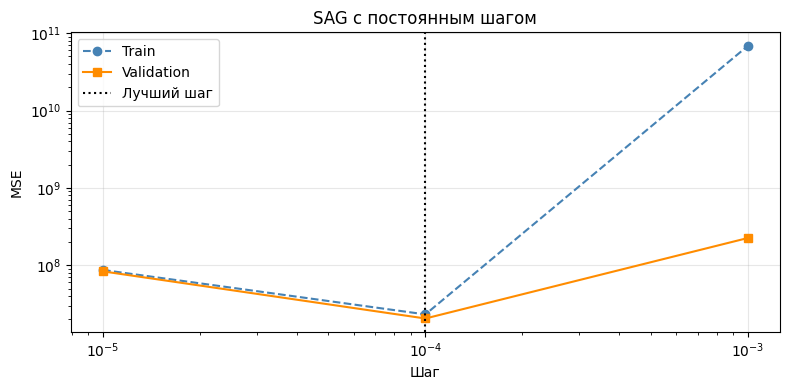

In [39]:
def train_sag(A, y, step, max_iter=5000):
    weights = np.zeros(A.shape[1])
    y = np.asarray(y)
    rng = np.random.default_rng(42)

    # Сохранённые градиенты всех объектов
    saved_gradients = np.zeros_like(A)
    mean_gradient = np.zeros(A.shape[1])

    for iteration in range(max_iter):
        # Выбираем один случайный объект
        index = rng.integers(len(y))

        prediction = A[index] @ weights
        new_gradient = 2 * (prediction - y[index]) * A[index]

        # Обновляем средний градиент и запоминаем новый
        mean_gradient += (
            new_gradient - saved_gradients[index]
        ) / len(y)
        saved_gradients[index] = new_gradient

        new_weights = weights - step * mean_gradient

        if not np.isfinite(new_weights).all() or np.linalg.norm(new_weights) > 1e12:
            return None, iteration + 1

        weights = new_weights

    return weights, max_iter


steps = np.logspace(-5, 0, 6)
results = []
models = []

for step in steps:
    weights, iterations = train_sag(A_train, y_train, step)
    models.append(weights)

    if weights is None:
        results.append({
            "Шаг": step,
            "Loss_train": np.inf,
            "R2_train": np.nan,
            "Loss_val": np.inf,
            "Итерации": iterations
        })
        continue

    train_predictions = A_train @ weights
    val_predictions = A_val @ weights

    results.append({
        "Шаг": step,
        "Loss_train": mean_squared_error(y_train, train_predictions),
        "R2_train": r2_score(y_train, train_predictions),
        "Loss_val": mean_squared_error(y_val, val_predictions),
        "Итерации": iterations
    })

results_sag = pd.DataFrame(results)
display(results_sag)

# Выбираем лучший шаг по ошибке на validation
best_index = results_sag["Loss_val"].idxmin()
best_weights = models[best_index]

# Оцениваем выбранную модель на test
test_predictions = A_test @ best_weights

sag_constant_result = {
    "Метод": "SAG с постоянным шагом",
    "Лучший шаг": results_sag.loc[best_index, "Шаг"],
    "Loss_train": results_sag.loc[best_index, "Loss_train"],
    "Loss_val": results_sag.loc[best_index, "Loss_val"],
    "Loss_test": mean_squared_error(y_test, test_predictions),
    "R2_train": results_sag.loc[best_index, "R2_train"],
    "R2_test": r2_score(y_test, test_predictions),
    "Итерации": int(results_sag.loc[best_index, "Итерации"])
}

display(pd.DataFrame([sag_constant_result]))
plot_losses(results_sag, "SAG с постоянным шагом")

9. Исследуйте SAG с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

,Лямбда,Loss_train,R2_train,Loss_val,Итерации
0,0.00001,1.087226e+08,-0.786366,1.066110e+08,5000
1,0.00010,1.039065e+08,-0.707236,1.013846e+08,5000
2,0.00100,6.862378e+07,-0.127523,6.370512e+07,5000
3,0.01000,1.425893e+07,0.765719,1.463025e+07,5000
4,0.10000,5.119208e+13,-841110.433782,9.708129e+10,5000
5,1.00000,inf,NaN,inf,2728


,Метод,Лучший шаг,Loss_train,Loss_val,Loss_test,R2_train,R2_test,Итерации
0,SAG с TimeDecayLR,0.01 / sqrt(1 + k),1.425893e+07,1.463025e+07,3.297661e+07,0.765719,0.527132,5000


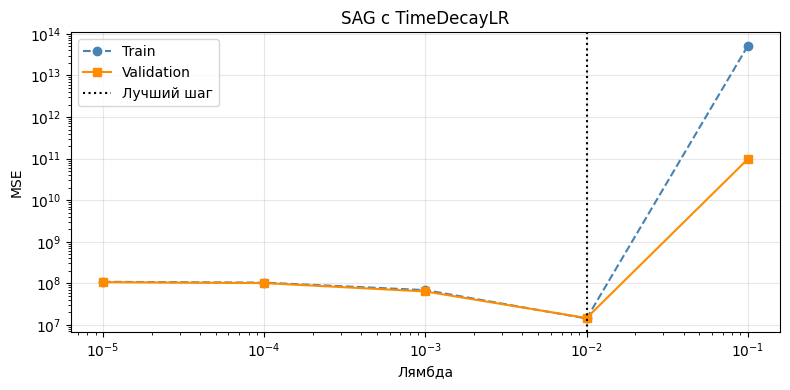

In [40]:
def train_sag_decay(A, y, learning_rate, max_iter=5000):
    weights = np.zeros(A.shape[1])
    y = np.asarray(y)
    rng = np.random.default_rng(42)

    # Сохранённые градиенты всех объектов
    saved_gradients = np.zeros_like(A)
    mean_gradient = np.zeros(A.shape[1])

    for iteration in range(max_iter):
        # Выбираем один случайный объект
        index = rng.integers(len(y))

        prediction = A[index] @ weights
        new_gradient = 2 * (prediction - y[index]) * A[index]

        # Обновляем средний градиент и запоминаем новый
        mean_gradient += (
            new_gradient - saved_gradients[index]
        ) / len(y)
        saved_gradients[index] = new_gradient

        # TimeDecayLR из лекции
        current_step = learning_rate / np.sqrt(1 + iteration)
        new_weights = weights - current_step * mean_gradient

        if not np.isfinite(new_weights).all() or np.linalg.norm(new_weights) > 1e12:
            return None, iteration + 1

        weights = new_weights

    return weights, max_iter


learning_rates = np.logspace(-5, 0, 6)
results = []
models = []

for learning_rate in learning_rates:
    weights, iterations = train_sag_decay(
        A_train, y_train, learning_rate
    )
    models.append(weights)

    if weights is None:
        results.append({
            "Лямбда": learning_rate,
            "Loss_train": np.inf,
            "R2_train": np.nan,
            "Loss_val": np.inf,
            "Итерации": iterations
        })
        continue

    train_predictions = A_train @ weights
    val_predictions = A_val @ weights

    results.append({
        "Лямбда": learning_rate,
        "Loss_train": mean_squared_error(y_train, train_predictions),
        "R2_train": r2_score(y_train, train_predictions),
        "Loss_val": mean_squared_error(y_val, val_predictions),
        "Итерации": iterations
    })

results_sag_decay = pd.DataFrame(results)
display(results_sag_decay)

# Выбираем лямбда по минимальной ошибке на validation
best_index = results_sag_decay["Loss_val"].idxmin()
best_weights = models[best_index]
best_lambda = results_sag_decay.loc[best_index, "Лямбда"]

# Оцениваем выбранную модель на test
test_predictions = A_test @ best_weights

sag_decay_result = {
    "Метод": "SAG с TimeDecayLR",
    "Лучший шаг": f"{best_lambda:.6g} / sqrt(1 + k)",
    "Loss_train": results_sag_decay.loc[best_index, "Loss_train"],
    "Loss_val": results_sag_decay.loc[best_index, "Loss_val"],
    "Loss_test": mean_squared_error(y_test, test_predictions),
    "R2_train": results_sag_decay.loc[best_index, "R2_train"],
    "R2_test": r2_score(y_test, test_predictions),
    "Итерации": int(results_sag_decay.loc[best_index, "Итерации"])
}

display(pd.DataFrame([sag_decay_result]))
plot_losses(results_sag_decay, "SAG с TimeDecayLR")

10. Исследуйте Momentum с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

,Шаг,Loss_train,R2_train,Loss_val,Итерации
0,0.00001,2.222412e+07,0.634847,2.031828e+07,5000
1,0.00010,1.271994e+07,0.791005,1.689978e+07,5000
2,0.00100,1.211564e+07,0.800934,1.755372e+07,5000
3,0.01000,1.202832e+07,0.802369,1.839784e+07,5000
4,0.10000,1.202827e+07,0.802369,1.843005e+07,3087
5,1.00000,inf,NaN,inf,12


,Метод,Лучший шаг,Loss_train,Loss_val,Loss_test,R2_train,R2_test,Итерации
0,Momentum с постоянным шагом,0.0001,1.271994e+07,1.689978e+07,2.877937e+07,0.791005,0.587318,5000


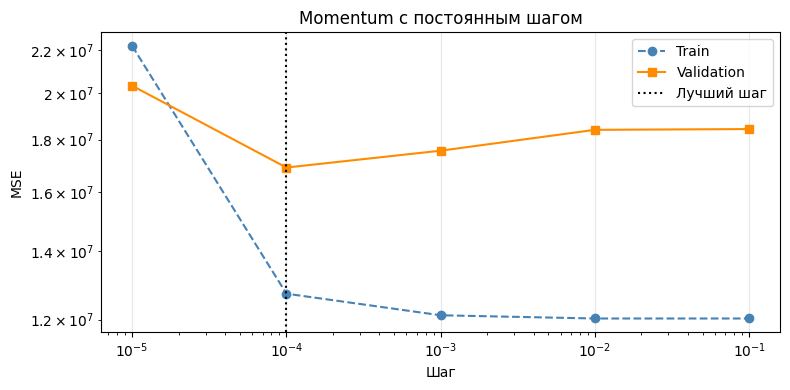

In [41]:
def train_momentum(A, y, step, max_iter=5000):
    weights = np.zeros(A.shape[1])
    impulse = np.zeros(A.shape[1])
    y = np.asarray(y)

    for iteration in range(max_iter):
        predictions = A @ weights
        gradient = 2 / len(y) * A.T @ (predictions - y)

        # Накапливаем импульс по формуле из лекции
        impulse = 0.9 * impulse + step * gradient
        new_weights = weights - impulse

        if not np.isfinite(new_weights).all() or np.linalg.norm(new_weights) > 1e12:
            return None, iteration + 1

        difference = np.linalg.norm(new_weights - weights)
        weights = new_weights

        if difference < 1e-6:
            break

    return weights, iteration + 1


steps = np.logspace(-5, 0, 6)
results = []
models = []

for step in steps:
    weights, iterations = train_momentum(A_train, y_train, step)
    models.append(weights)

    if weights is None:
        results.append({
            "Шаг": step,
            "Loss_train": np.inf,
            "R2_train": np.nan,
            "Loss_val": np.inf,
            "Итерации": iterations
        })
        continue

    train_predictions = A_train @ weights
    val_predictions = A_val @ weights

    results.append({
        "Шаг": step,
        "Loss_train": mean_squared_error(y_train, train_predictions),
        "R2_train": r2_score(y_train, train_predictions),
        "Loss_val": mean_squared_error(y_val, val_predictions),
        "Итерации": iterations
    })

results_momentum = pd.DataFrame(results)
display(results_momentum)

# Выбираем лучший шаг по ошибке на validation
best_index = results_momentum["Loss_val"].idxmin()
best_weights = models[best_index]

# Оцениваем выбранную модель на test
test_predictions = A_test @ best_weights

momentum_constant_result = {
    "Метод": "Momentum с постоянным шагом",
    "Лучший шаг": results_momentum.loc[best_index, "Шаг"],
    "Loss_train": results_momentum.loc[best_index, "Loss_train"],
    "Loss_val": results_momentum.loc[best_index, "Loss_val"],
    "Loss_test": mean_squared_error(y_test, test_predictions),
    "R2_train": results_momentum.loc[best_index, "R2_train"],
    "R2_test": r2_score(y_test, test_predictions),
    "Итерации": int(results_momentum.loc[best_index, "Итерации"])
}

display(pd.DataFrame([momentum_constant_result]))
plot_losses(results_momentum, "Momentum с постоянным шагом")

11. Исследуйте Momentum с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

,Лямбда,Loss_train,R2_train,Loss_val,Итерации
0,0.00001,1.009473e+08,-0.658614,9.839301e+07,5000
1,0.00010,5.608655e+07,0.078470,5.197384e+07,5000
2,0.00100,1.359155e+07,0.776684,1.529971e+07,5000
3,0.01000,1.241376e+07,0.796036,1.742671e+07,5000
4,0.10000,1.203343e+07,0.802285,1.797834e+07,5000
5,1.00000,1.202827e+07,0.802369,1.842984e+07,5000


,Метод,Лучший шаг,Loss_train,Loss_val,Loss_test,R2_train,R2_test,Итерации
0,Momentum с TimeDecayLR,0.001 / sqrt(1 + k),1.359155e+07,1.529971e+07,3.065702e+07,0.776684,0.560394,5000


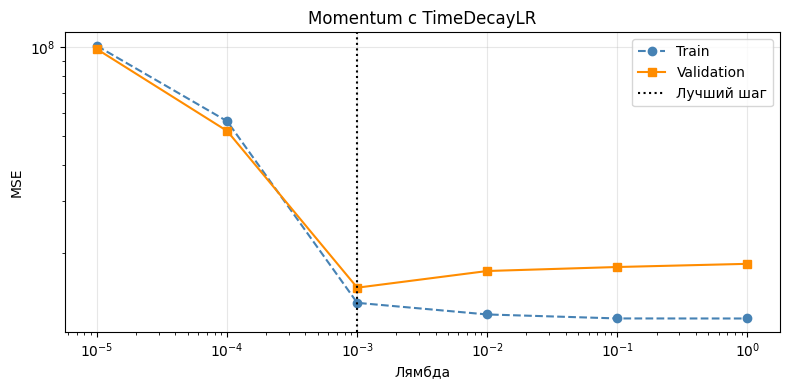

In [42]:
def train_momentum_decay(A, y, learning_rate, max_iter=5000):
    weights = np.zeros(A.shape[1])
    impulse = np.zeros(A.shape[1])
    y = np.asarray(y)

    for iteration in range(max_iter):
        predictions = A @ weights
        gradient = 2 / len(y) * A.T @ (predictions - y)

        # TimeDecayLR из лекции
        current_step = learning_rate / np.sqrt(1 + iteration)

        # Накапливаем импульс
        impulse = 0.9 * impulse + current_step * gradient
        new_weights = weights - impulse

        if not np.isfinite(new_weights).all() or np.linalg.norm(new_weights) > 1e12:
            return None, iteration + 1

        difference = np.linalg.norm(new_weights - weights)
        weights = new_weights

        if difference < 1e-6:
            break

    return weights, iteration + 1


learning_rates = np.logspace(-5, 0, 6)
results = []
models = []

for learning_rate in learning_rates:
    weights, iterations = train_momentum_decay(
        A_train, y_train, learning_rate
    )
    models.append(weights)

    if weights is None:
        results.append({
            "Лямбда": learning_rate,
            "Loss_train": np.inf,
            "R2_train": np.nan,
            "Loss_val": np.inf,
            "Итерации": iterations
        })
        continue

    train_predictions = A_train @ weights
    val_predictions = A_val @ weights

    results.append({
        "Лямбда": learning_rate,
        "Loss_train": mean_squared_error(y_train, train_predictions),
        "R2_train": r2_score(y_train, train_predictions),
        "Loss_val": mean_squared_error(y_val, val_predictions),
        "Итерации": iterations
    })

results_momentum_decay = pd.DataFrame(results)
display(results_momentum_decay)

# Выбираем лямбда по минимальной ошибке на validation
best_index = results_momentum_decay["Loss_val"].idxmin()
best_weights = models[best_index]
best_lambda = results_momentum_decay.loc[best_index, "Лямбда"]

# Оцениваем выбранную модель на test
test_predictions = A_test @ best_weights

momentum_decay_result = {
    "Метод": "Momentum с TimeDecayLR",
    "Лучший шаг": f"{best_lambda:.6g} / sqrt(1 + k)",
    "Loss_train": results_momentum_decay.loc[best_index, "Loss_train"],
    "Loss_val": results_momentum_decay.loc[best_index, "Loss_val"],
    "Loss_test": mean_squared_error(y_test, test_predictions),
    "R2_train": results_momentum_decay.loc[best_index, "R2_train"],
    "R2_test": r2_score(y_test, test_predictions),
    "Итерации": int(results_momentum_decay.loc[best_index, "Итерации"])
}

display(pd.DataFrame([momentum_decay_result]))
plot_losses(results_momentum_decay, "Momentum с TimeDecayLR")


12. Исследуйте Adam с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

,Шаг,Loss_train,R2_train,Loss_val,Итерации
0,0.00001,1.092669e+08,-0.795309,1.072018e+08,5000
1,0.00010,1.091859e+08,-0.793978,1.071074e+08,5000
2,0.00100,1.083842e+08,-0.780806,1.061710e+08,5000
3,0.01000,1.011326e+08,-0.661659,9.767378e+07,5000
4,0.10000,6.848522e+07,-0.125246,6.188237e+07,5000
5,1.00000,1.909599e+07,0.686243,2.293881e+07,5000


,Метод,Лучший шаг,Loss_train,Loss_val,Loss_test,R2_train,R2_test,Итерации
0,Adam с постоянным шагом,1.0,1.909599e+07,2.293881e+07,4.321281e+07,0.686243,0.38035,5000


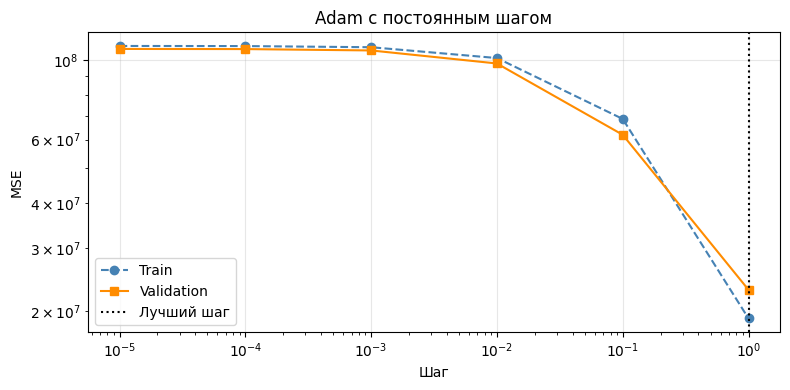

In [43]:
def train_adam(A, y, step, max_iter=5000):
    weights = np.zeros(A.shape[1])
    y = np.asarray(y)

    first_moment = np.zeros(A.shape[1])
    second_moment = np.zeros(A.shape[1])

    beta1 = 0.9
    beta2 = 0.999
    epsilon = 1e-8

    for iteration in range(max_iter):
        predictions = A @ weights
        gradient = 2 / len(y) * A.T @ (predictions - y)

        # Обновляем моменты градиента
        first_moment = beta1 * first_moment + (1 - beta1) * gradient
        second_moment = beta2 * second_moment + (1 - beta2) * gradient**2

        # Корректируем начальное смещение
        corrected_first = first_moment / (1 - beta1**(iteration + 1))
        corrected_second = second_moment / (1 - beta2**(iteration + 1))

        new_weights = weights - step * corrected_first / (
            np.sqrt(corrected_second) + epsilon
        )

        if not np.isfinite(new_weights).all() or np.linalg.norm(new_weights) > 1e12:
            return None, iteration + 1

        difference = np.linalg.norm(new_weights - weights)
        weights = new_weights

        if difference < 1e-6:
            break

    return weights, iteration + 1


steps = np.logspace(-5, 0, 6)
results = []
models = []

for step in steps:
    weights, iterations = train_adam(A_train, y_train, step)
    models.append(weights)

    if weights is None:
        results.append({
            "Шаг": step,
            "Loss_train": np.inf,
            "R2_train": np.nan,
            "Loss_val": np.inf,
            "Итерации": iterations
        })
        continue

    train_predictions = A_train @ weights
    val_predictions = A_val @ weights

    results.append({
        "Шаг": step,
        "Loss_train": mean_squared_error(y_train, train_predictions),
        "R2_train": r2_score(y_train, train_predictions),
        "Loss_val": mean_squared_error(y_val, val_predictions),
        "Итерации": iterations
    })

results_adam = pd.DataFrame(results)
display(results_adam)

# Выбираем лучший шаг по ошибке на validation
best_index = results_adam["Loss_val"].idxmin()
best_weights = models[best_index]

# Оцениваем выбранную модель на test
test_predictions = A_test @ best_weights

adam_constant_result = {
    "Метод": "Adam с постоянным шагом",
    "Лучший шаг": results_adam.loc[best_index, "Шаг"],
    "Loss_train": results_adam.loc[best_index, "Loss_train"],
    "Loss_val": results_adam.loc[best_index, "Loss_val"],
    "Loss_test": mean_squared_error(y_test, test_predictions),
    "R2_train": results_adam.loc[best_index, "R2_train"],
    "R2_test": r2_score(y_test, test_predictions),
    "Итерации": int(results_adam.loc[best_index, "Итерации"])
}

display(pd.DataFrame([adam_constant_result]))

# График зависимости ошибки от шага
plot_losses(results_adam, "Adam с постоянным шагом")


13. Исследуйте Adam с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

,Лямбда,Loss_train,R2_train,Loss_val,Итерации
0,0.00001,1.092756e+08,-0.795453,1.072120e+08,5000
1,0.00010,1.092733e+08,-0.795416,1.072093e+08,5000
2,0.00100,1.092507e+08,-0.795043,1.071829e+08,5000
3,0.01000,1.090244e+08,-0.791325,1.069190e+08,5000
4,0.10000,1.068216e+08,-0.755132,1.043448e+08,5000
5,1.00000,8.986436e+07,-0.476516,8.443914e+07,5000


,Метод,Лучший шаг,Loss_train,Loss_val,Loss_test,R2_train,R2_test,Итерации
0,Adam с TimeDecayLR,1 / sqrt(1 + k),8.986436e+07,8.443914e+07,1.194979e+08,-0.476516,-0.713539,5000


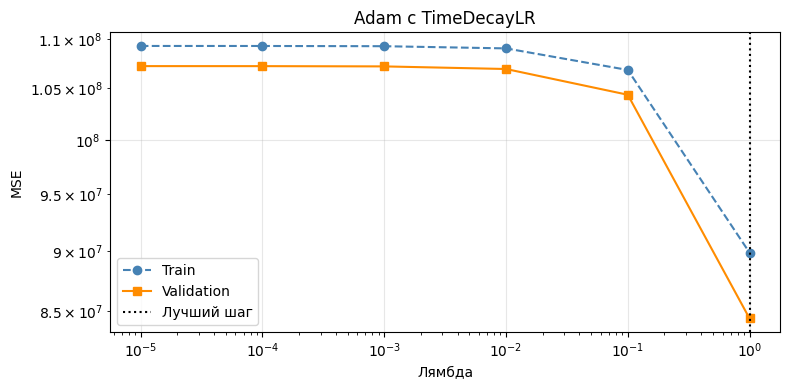

In [46]:
def train_adam_decay(A, y, learning_rate, max_iter=5000):
    weights = np.zeros(A.shape[1])
    y = np.asarray(y)

    first_moment = np.zeros(A.shape[1])
    second_moment = np.zeros(A.shape[1])

    beta1 = 0.9
    beta2 = 0.999
    epsilon = 1e-8

    for iteration in range(max_iter):
        predictions = A @ weights
        gradient = 2 / len(y) * A.T @ (predictions - y)

        # Обновляем моменты градиента
        first_moment = beta1 * first_moment + (1 - beta1) * gradient
        second_moment = beta2 * second_moment + (1 - beta2) * gradient**2

        # Корректируем начальное смещение
        corrected_first = first_moment / (1 - beta1**(iteration + 1))
        corrected_second = second_moment / (1 - beta2**(iteration + 1))

        # TimeDecayLR из лекции
        current_step = learning_rate / np.sqrt(1 + iteration)

        new_weights = weights - current_step * corrected_first / (
            np.sqrt(corrected_second) + epsilon
        )

        if not np.isfinite(new_weights).all() or np.linalg.norm(new_weights) > 1e12:
            return None, iteration + 1

        difference = np.linalg.norm(new_weights - weights)
        weights = new_weights

        if difference < 1e-6:
            break

    return weights, iteration + 1


learning_rates = np.logspace(-5, 0, 6)
results = []
models = []

for learning_rate in learning_rates:
    weights, iterations = train_adam_decay(
        A_train, y_train, learning_rate
    )
    models.append(weights)

    if weights is None:
        results.append({
            "Лямбда": learning_rate,
            "Loss_train": np.inf,
            "R2_train": np.nan,
            "Loss_val": np.inf,
            "Итерации": iterations
        })
        continue

    train_predictions = A_train @ weights
    val_predictions = A_val @ weights

    results.append({
        "Лямбда": learning_rate,
        "Loss_train": mean_squared_error(y_train, train_predictions),
        "R2_train": r2_score(y_train, train_predictions),
        "Loss_val": mean_squared_error(y_val, val_predictions),
        "Итерации": iterations
    })

results_adam_decay = pd.DataFrame(results)
display(results_adam_decay)

# Выбираем лямбда по минимальной ошибке на validation
best_index = results_adam_decay["Loss_val"].idxmin()
best_weights = models[best_index]
best_lambda = results_adam_decay.loc[best_index, "Лямбда"]

# Оцениваем выбранную модель на test
test_predictions = A_test @ best_weights

adam_decay_result = {
    "Метод": "Adam с TimeDecayLR",
    "Лучший шаг": f"{best_lambda:.6g} / sqrt(1 + k)",
    "Loss_train": results_adam_decay.loc[best_index, "Loss_train"],
    "Loss_val": results_adam_decay.loc[best_index, "Loss_val"],
    "Loss_test": mean_squared_error(y_test, test_predictions),
    "R2_train": results_adam_decay.loc[best_index, "R2_train"],
    "R2_test": r2_score(y_test, test_predictions),
    "Итерации": int(results_adam_decay.loc[best_index, "Итерации"])
}

display(pd.DataFrame([adam_decay_result]))

# График зависимости ошибки от лямбда
plot_losses(results_adam_decay, "Adam с TimeDecayLR")

14. Постройте итоговую сравнительную таблицу со следующими столбцами:

1) название метода

2) значение лучшего шага (если n) или функция лучшего шага (если n(lyamda))

3) Loss_train

4) Loss_test

5) R^2 train

6) R^2 test

7) число итераций на test

In [47]:
comparison = pd.DataFrame([
    vgd_constant_result,
    vgd_decay_result,
    sgd_constant_result,
    sgd_decay_result,
    sag_constant_result,
    sag_decay_result,
    momentum_constant_result,
    momentum_decay_result,
    adam_constant_result,
    adam_decay_result
])

# Столбцы по условию задания
columns = [
    "Метод",
    "Лучший шаг",
    "Loss_train",
    "Loss_test",
    "R2_train",
    "R2_test",
    "Итерации"
]

display(comparison[columns].round(4))

,Метод,Лучший шаг,Loss_train,Loss_test,R2_train,R2_test,Итерации
0,VGD с постоянным шагом,0.001,1.271979e+07,2.878046e+07,0.7910,0.5873,5000
1,VGD с TimeDecayLR,0.01 / sqrt(1 + k),1.360320e+07,3.068854e+07,0.7765,0.5599,5000
2,SGD с постоянным шагом,0.0001,2.133809e+07,3.906959e+07,0.6494,0.4398,5000
3,SGD с TimeDecayLR,0.01 / sqrt(1 + k),1.420092e+07,3.134007e+07,0.7667,0.5506,5000
4,SAG с постоянным шагом,0.0001,2.318709e+07,4.412218e+07,0.6190,0.3673,5000
5,SAG с TimeDecayLR,0.01 / sqrt(1 + k),1.425893e+07,3.297661e+07,0.7657,0.5271,5000
6,Momentum с постоянным шагом,0.0001,1.271994e+07,2.877937e+07,0.7910,0.5873,5000
7,Momentum с TimeDecayLR,0.001 / sqrt(1 + k),1.359155e+07,3.065702e+07,0.7767,0.5604,5000
8,Adam с постоянным шагом,1.0,1.909599e+07,4.321281e+07,0.6862,0.3804,5000
9,Adam с TimeDecayLR,1 / sqrt(1 + k),8.986436e+07,1.194979e+08,-0.4765,-0.7135,5000


15. Сделайте вывод о том, какой метод и шаг линейной регрессии самый лучший для данной выборки и ответьте на вопросы:

1) почему именно этот метод и этот шаг самый лучший (по каким данным из таблицы вы сделали такой вывод)

2) расскажите простыми словами суть R^2_train и R^2_test?

3) как R^2_train и R^2_test помогают сравнивать методы? почему оба эти значения надо вычислять для данного выбора?

Вывод
Самый лучший метод Momentum с постоянным шагом 0,001

1. Именно этот метод потому что у него минимальная ошибка на валидационных данных

2. R^2_train показывает насколько ошибка модели меньше по сравнению с естественным разбросом целевой переменной на обучающей выборке. Если это значение сликом большое, значит модель хорошо приспособилась к обучающим данным, а R^2_test показывает сохранилась ли способность хорошо предсказывать значения на текстовой выборке 

3. По первому значению мы определяем насоклько хорошо мы описываем обучающие данные, а по второму на тестовых, нельзя делать вывод о переобученности или недообученности модели только на основе одного показателя.
